In [5]:
import numpy as np
import matplotlib.pyplot as plt

## Hill functions. Do stepping at some point?

In [ ]:
def h_plus(p, theta, n, eps=1e-12):
    p = np.maximum(p, 0.0)
    return (p**n) / (theta**n + p**n + eps)

def h_minus(p, theta, n, eps=1e-12):
    p = np.maximum(p, 0.0)
    return (theta**n) / (theta**n + p**n + eps)

In [3]:
def simulate_two_gene_sdevelo(params, T=10.0, dt=0.01, seed=0, clamp_nonneg=True):
    """
    2-gene model:
      SDE for (U_A, S_A, U_B, S_B)
      ODE for (p_A, p_B) 

    params: a dictionary of parameters for sdes
    T: simulation time
    dt: time step
    seed: seed
    clamp_noneg: physical constraints, stops from going negative if noise weird
    """
    rng = np.random.default_rng(seed)
    N = int(np.ceil(T / dt))
    t = np.linspace(0, N*dt, N+1)
    sqrt_dt = np.sqrt(dt)

    
    aA, aB = params["aA"], params["aB"]
    mA, mB = params["mA"], params["mB"]
    betaA, betaB = params["betaA"], params["betaB"]
    gammaA, gammaB = params["gammaA"], params["gammaB"]
    nA, nB = params["nA"], params["nB"]
    thA, thB = params["thetaA"], params["thetaB"]
    kPA, kPB = params["kPA"], params["kPB"]
    dPA, dPB = params["deltaPA"], params["deltaPB"]
    s1A, s2A = params["sigma1A"], params["sigma2A"]
    s1B, s2B = params["sigma1B"], params["sigma2B"]

    # initial conditions
    UA = np.zeros(N+1); SA = np.zeros(N+1)
    UB = np.zeros(N+1); SB = np.zeros(N+1)
    pA = np.zeros(N+1); pB = np.zeros(N+1)

    UA[0] = params["UA0"]; SA[0] = params["SA0"]
    UB[0] = params["UB0"]; SB[0] = params["SB0"]
    pA[0] = params["pA0"]; pB[0] = params["pB0"]

    for k in range(N):
        # applied hill functions
        act_A = h_plus(pB[k], thB, nB)   # pB activates A (and promotes A splicing)
        rep_B = h_minus(pA[k], thA, nA)  # pA represses B (and inhibits B splicing)

        # transcription into unspliced
        alphaA = aA + mA * act_A
        alphaB = aB + mB * rep_B

        # splicing rates (dotted edges)
        betaA_star = betaA * act_A
        betaB_star = betaB * rep_B

        # independent noises for dbt
        xi_UA, xi_SA, xi_UB, xi_SB = rng.normal(size=4)

        
        UA[k+1] = UA[k] + (alphaA - betaA_star * UA[k]) * dt + s1A * sqrt_dt * xi_UA
        SA[k+1] = SA[k] + (betaA_star * UA[k] - gammaA * SA[k]) * dt + s2A * sqrt_dt * xi_SA

        UB[k+1] = UB[k] + (alphaB - betaB_star * UB[k]) * dt + s1B * sqrt_dt * xi_UB
        SB[k+1] = SB[k] + (betaB_star * UB[k] - gammaB * SB[k]) * dt + s2B * sqrt_dt * xi_SB

        pA[k+1] = pA[k] + (kPA * SA[k] - dPA * pA[k]) * dt
        pB[k+1] = pB[k] + (kPB * SB[k] - dPB * pB[k]) * dt

        if clamp_nonneg:
            UA[k+1] = max(UA[k+1], 0.0); SA[k+1] = max(SA[k+1], 0.0)
            UB[k+1] = max(UB[k+1], 0.0); SB[k+1] = max(SB[k+1], 0.0)
            pA[k+1] = max(pA[k+1], 0.0); pB[k+1] = max(pB[k+1], 0.0)

    return t, UA, SA, UB, SB, pA, pB




In [4]:

params = dict(
    aA=1.0, aB=0.25,
    mA=2.35, mB=2.35,
    betaA=2.35, betaB=2.35,
    gammaA=1.0, gammaB=1.0,
    nA=3, nB=3,
    thetaA=0.21, thetaB=0.21,
    kPA=1.0, kPB=1.0,
    deltaPA=1.0, deltaPB=1.0,      
    sigma1A=0.05, sigma2A=0.05,
    sigma1B=0.05, sigma2B=0.05,
    UA0=0.8, SA0=0.8,
    UB0=0.8, SB0=0.8,
    pA0=0.8, pB0=0.8,
)


t, UA, SA, UB, SB, pA, pB = simulate_two_gene_sdevelo(params, T=10.0, dt=0.01, seed=1)

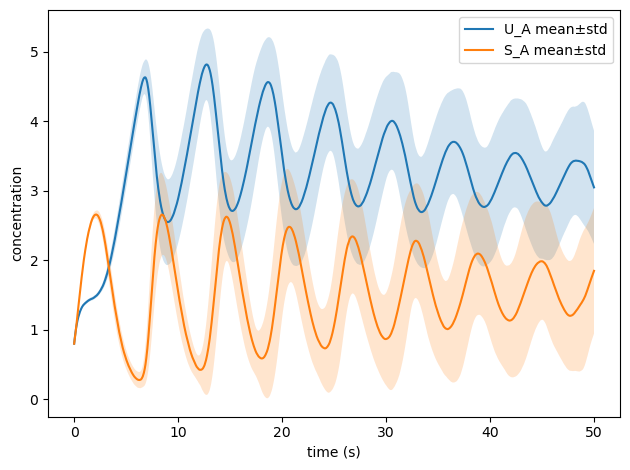

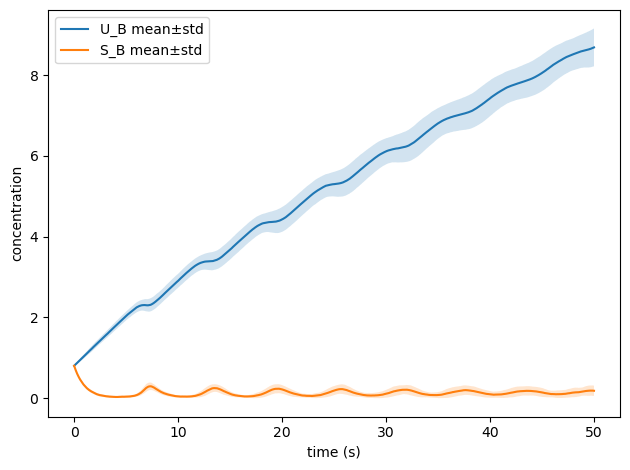

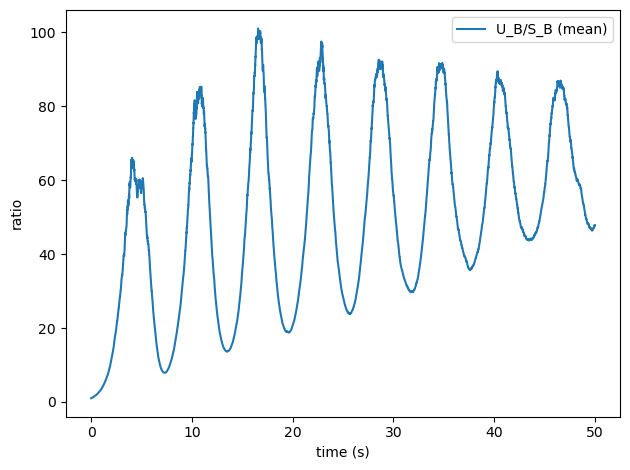

In [13]:

def run_ensemble(sim_fn, params, T=10.0, dt=0.01, n_runs=200, seed=0):
    rng = np.random.default_rng(seed)
    series = []
    for r in range(n_runs):
        s = sim_fn(params, T=T, dt=dt, seed=int(rng.integers(1e9)))
        # s = (t, UA, SA, UB, SB, pA, pB)
        series.append(s[1:])  # drop t, keep arrays
    
    stacked = np.stack([np.stack(x, axis=0) for x in series], axis=0)
    mean = stacked.mean(axis=0)
    std  = stacked.std(axis=0)
    return mean, std

def plot_band(t, y_mean, y_std, label):
    plt.plot(t, y_mean, label=label)
    plt.fill_between(t, y_mean - y_std, y_mean + y_std, alpha=0.2)


t, UA, SA, UB, SB, pA, pB = simulate_two_gene_sdevelo(params, T=50.0, dt=0.01, seed=1)

mean, std = run_ensemble(simulate_two_gene_sdevelo, params, T=50.0, dt=0.01, n_runs=200)

UA_m, SA_m, UB_m, SB_m, pA_m, pB_m = mean
UA_s, SA_s, UB_s, SB_s, pA_s, pB_s = std

plt.figure()
plot_band(t, UA_m, UA_s, "U_A mean±std")
plot_band(t, SA_m, SA_s, "S_A mean±std")
plt.xlabel("time (s)"); plt.ylabel("concentration")
plt.legend(); plt.tight_layout()

plt.figure()
plot_band(t, UB_m, UB_s, "U_B mean±std")
plot_band(t, SB_m, SB_s, "S_B mean±std")
plt.xlabel("time (s)"); plt.ylabel("concentration")
plt.legend(); plt.tight_layout()

#buildup mrna
ratio_m = UB_m / (SB_m + 1e-12)
ratio_s = UB_s / (SB_m + 1e-12)  
plt.figure()
plt.plot(t, ratio_m, label="U_B/S_B (mean)")
plt.xlabel("time (s)"); plt.ylabel("ratio")
plt.legend(); plt.tight_layout()

plt.show()